# Dataset-Level Attribution Analysis (Camargo Sepsis)

Camargo port of `henryk/{bpic17,helpdesk}/02_dataset_attribution_analysis.ipynb`.

For every prefix in the test set (including the case-end prefix where the next event
is EOS), runs Integrated Gradients on the Camargo single-step model and aggregates
`|attribution|.sum()` per input feature. Then visualizes:

1. **Average feature attribution** across the dataset
2. **Attribution by prefix length**
3. **Attribution by predicted next activity** (top-5 most common)
4. **Attribution heatmap** (activity x feature)

Use `TEST_MODE = True` for a fast subset; flip to `False` for full-dataset runs.


## 1. Setup

In [14]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Liberation Serif', 'DejaVu Serif']
import seaborn as sns
import pickle
import random
from collections import defaultdict
from tqdm.notebook import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
get_ipython().run_line_magic('matplotlib', 'inline')


In [15]:
from src.interpretability.config.sepsis_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant

SPEC = utils.SEPSIS
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

model = utils.load_camargo_model(_current, SPEC)
dataset = utils.load_test_dataset(_current, SPEC)
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
ACT_IDX = SPEC.cat_indices[0]
idx_to_name = predictor.idx_to_name
eos_idx = predictor.eos_idx

# Derive feature names from the dataset + SPEC so old / improved variants both work.
# `dataset.all_categories` is `(cat_specs, num_specs)`, each entry `(name, n_classes, vocab)`.
# SPEC.cat_indices / SPEC.num_indices select the columns the model actually consumes.
_all_cat_specs = dataset.all_categories[0]
_all_num_specs = dataset.all_categories[1]
FEATURE_CAT_NAMES = [_all_cat_specs[i][0] for i in SPEC.cat_indices]
FEATURE_NUM_NAMES = [_all_num_specs[i][0] for i in SPEC.num_indices]
FEATURE_NAMES = FEATURE_CAT_NAMES + FEATURE_NUM_NAMES

print(f'Model: {SPEC.name} | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')
print(f'Categorical features ({len(FEATURE_CAT_NAMES)}): {FEATURE_CAT_NAMES}')
print(f'Numerical features ({len(FEATURE_NUM_NAMES)}): {FEATURE_NUM_NAMES}')


Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26})], [('case_elapsed_time', 1, {})])
Model input features:  [['concept:name', 'org:group'], ['case_elapsed_time']]
Embeddings:  ModuleList(
  (0): Embedding(18, 8)
  (1): Embedding(27, 10)
)
Total embedding feature size:  18
Number of numerical features:  1
Input feature size (shared LSTM, cat-only):  18
Cells hidden size:  50
Number of LSTM layer:  1
Model: Sepsis | window=5 | vocab=18 classes | |test|=3251
Ca

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


## 2. Configuration

In [16]:
TEST_MODE = False             # Set False for full-dataset analysis
TEST_SAMPLE_SIZE = 200       # Samples to use in test mode
IG_STEPS = 30                # Integration steps (smaller = faster, noisier)

print(f'Mode: {"TEST" if TEST_MODE else "FULL"}')


Mode: FULL


## 3. Prepare Samples

`iter_case_prefixes(..., include_end=True)` yields the prefix that ends at the last real
activity too (next event = EOS), so case-end attribution lands in the dataset average.

In [17]:
# Unique cases (longest trace per case_id)
cases = {}
for i in range(len(dataset)):
    cat_t, _, cid = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if cid not in cases or trace_len > cases[cid][1]:
        cases[cid] = (i, trace_len)

# Collect (case_id, ds_idx, prefix_length, start) tuples for every prefix
all_samples = []
for cid, (ds_idx, _) in cases.items():
    cats_full, _, _ = dataset[ds_idx]
    cats_proj, _ = utils.project_features(cats_full, dataset[ds_idx][1], SPEC)
    for prefix_length, start, useful_len in utils.iter_case_prefixes(
        [cats_proj[0]], acts_tensor_idx=0, eos_idx=eos_idx, include_end=True,
    ):
        all_samples.append({'case_id': cid, 'ds_idx': ds_idx,
                            'prefix_length': prefix_length, 'start': start,
                            'useful_len': useful_len})

print(f'Total prefix samples: {len(all_samples)}')

if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f'Using {len(samples)} samples (test mode)')
else:
    samples = all_samples
    print(f'Using all {len(samples)} samples (full mode)')


Total prefix samples: 2813
Using all 2813 samples (full mode)


## 4. Compute Attributions

In [18]:
attribution_results = []

for s in tqdm(samples, desc='Computing IG'):
    cats_full, nums_full, _ = dataset[s['ds_idx']]
    start = s['start']
    prefix_length = s['prefix_length']
    useful_len = s['useful_len']

    # Build the prefix window for the Camargo model
    cats_win, nums_win = utils.make_prefix_window(
        cats_full, nums_full, start=start,
        prefix_length=prefix_length, window=window, spec=SPEC,
    )

    # Predicted next activity (used as the IG target class)
    pred_idx, _ = predictor.predict_batch(cats_win, nums_win)
    target = int(pred_idx.item())
    pred_name = idx_to_name.get(target, f'<{target}>')

    # Actual next activity (EOS when prefix ends at the last real event)
    acts_proj = utils.project_features(cats_full, nums_full, SPEC)[0][0].tolist()
    if prefix_length < useful_len:
        actual_idx = acts_proj[start + prefix_length]
        actual_name = idx_to_name.get(actual_idx)
    else:
        actual_name = 'EOS'

    try:
        cat_attrs, num_attrs = utils.compute_integrated_gradients(
            model, cats_win, nums_win, target_class=target, n_steps=IG_STEPS,
        )
    except Exception as e:
        print(f'IG failed for {s["case_id"]} prefix={prefix_length}: {e}')
        continue

    # Aggregate |attribution|.sum() per input feature. cat_attrs / num_attrs are
    # ordered by SPEC.cat_indices / SPEC.num_indices, which matches FEATURE_CAT_NAMES
    # / FEATURE_NUM_NAMES exactly.
    if len(cat_attrs) != len(FEATURE_CAT_NAMES):
        raise RuntimeError(
            f'Cat attribution count ({len(cat_attrs)}) != FEATURE_CAT_NAMES '
            f'({len(FEATURE_CAT_NAMES)}) — SPEC.cat_indices and the loaded '
            f'model disagree about input shape.'
        )
    if len(num_attrs) != len(FEATURE_NUM_NAMES):
        raise RuntimeError(
            f'Num attribution count ({len(num_attrs)}) != FEATURE_NUM_NAMES '
            f'({len(FEATURE_NUM_NAMES)}).'
        )
    attr_per_feature = {}
    for i, name in enumerate(FEATURE_CAT_NAMES):
        attr_per_feature[name] = float(cat_attrs[i].abs().sum().item())
    for j, name in enumerate(FEATURE_NUM_NAMES):
        attr_per_feature[name] = float(num_attrs[j].abs().sum().item())

    attribution_results.append({
        'case_id': s['case_id'],
        'prefix_length': prefix_length,
        'predicted_activity': pred_name,
        'actual_next_activity': actual_name,
        **attr_per_feature,
    })

results_df = pd.DataFrame(attribution_results)
print(f'Computed attributions for {len(results_df)} prefixes')
print(f'EOS-target prefixes: {(results_df["actual_next_activity"] == "EOS").sum()}')
print(f'Per-feature columns ({len([c for c in results_df.columns if c in FEATURE_NAMES])} of {len(FEATURE_NAMES)}): '
      f'{[c for c in FEATURE_NAMES if c in results_df.columns][:6]}{"..." if len(FEATURE_NAMES) > 6 else ""}')


Computing IG:   0%|          | 0/2813 [00:00<?, ?it/s]

Computed attributions for 2813 prefixes
EOS-target prefixes: 209
Per-feature columns (3 of 3): ['concept:name', 'org:group', 'case_elapsed_time']


## 5. Average Feature Attribution

In [19]:
available_features = [f for f in FEATURE_NAMES if f in results_df.columns]
avg_attribution = results_df[available_features].mean()
std_attribution = results_df[available_features].std()

print('Average Feature Attribution:')
print('=' * 60)
for feat in available_features:
    print(f'{feat:25s}: {avg_attribution[feat]:.6f} +/- {std_attribution[feat]:.6f}')


Average Feature Attribution:
concept:name             : 1.459666 +/- 0.562374
org:group                : 1.032362 +/- 0.460971
case_elapsed_time        : 0.040990 +/- 0.034741


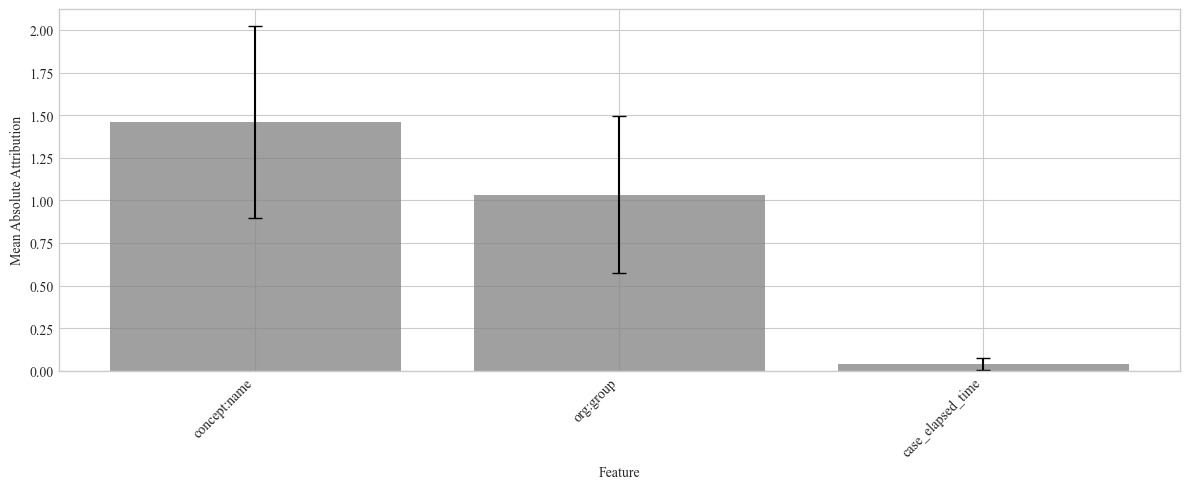

In [31]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Liberation Serif', 'DejaVu Serif']

fig, ax = plt.subplots(figsize=(12, 5))
colors = '#888888'  # neutral grey applied uniformly to all bars
ax.bar(available_features, avg_attribution[available_features],
       yerr=std_attribution[available_features], capsize=5,
       color=colors, alpha=0.8)
ax.set_ylabel('Mean Absolute Attribution')
ax.set_xlabel('Feature')
#ax.set_title(f'Average Feature Attribution ({SPEC.name})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


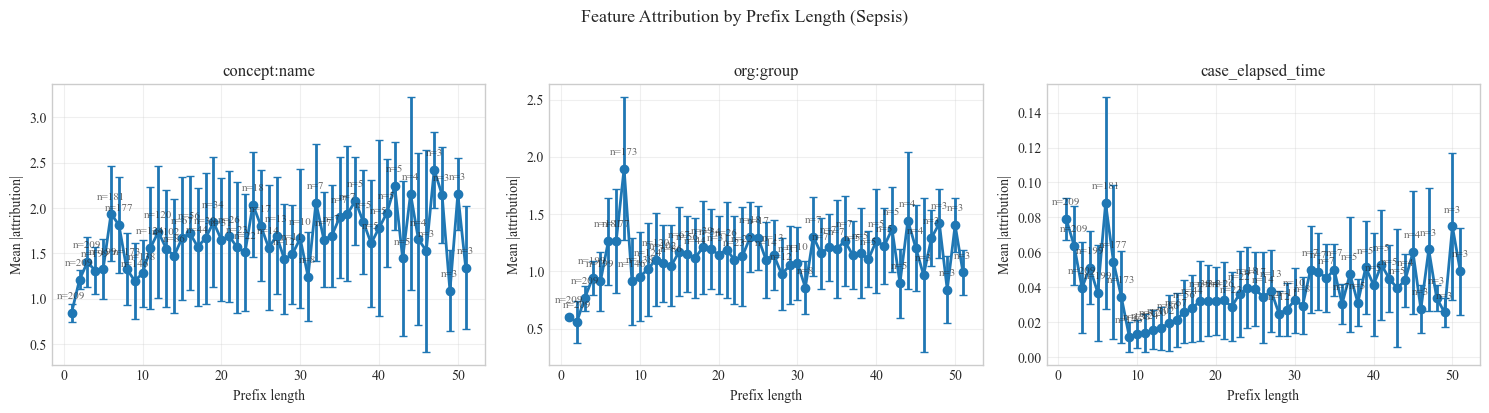

In [21]:
# Attribution by prefix length
n_features = len(available_features)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten() if n_features > 1 else [axes]

prefix_counts = results_df.groupby('prefix_length').size()
for idx, feat in enumerate(available_features):
    ax = axes[idx]
    grouped = results_df.groupby('prefix_length')[feat].agg(['mean', 'std'])
    ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'],
                marker='o', capsize=3, linewidth=2, markersize=6)
    ax.set_xlabel('Prefix length')
    ax.set_ylabel('Mean |attribution|')
    ax.set_title(feat)
    ax.grid(True, alpha=0.3)
    for pl in grouped.index:
        ax.annotate(f'n={prefix_counts[pl]}', (pl, grouped.loc[pl, 'mean']),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8, alpha=0.7)
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Prefix Length ({SPEC.name})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Attribution by Predicted Next Activity

In [22]:
activity_counts = results_df['predicted_activity'].value_counts()
top_activities = activity_counts.head(5).index.tolist()
print('Top 5 predicted next activities:')
for act in top_activities:
    print(f'  {act}: {activity_counts[act]} predictions')


Top 5 predicted next activities:
  Leucocytes: 754 predictions
  CRP: 598 predictions
  ER Triage: 231 predictions
  ER Sepsis Triage: 226 predictions
  LacticAcid: 226 predictions


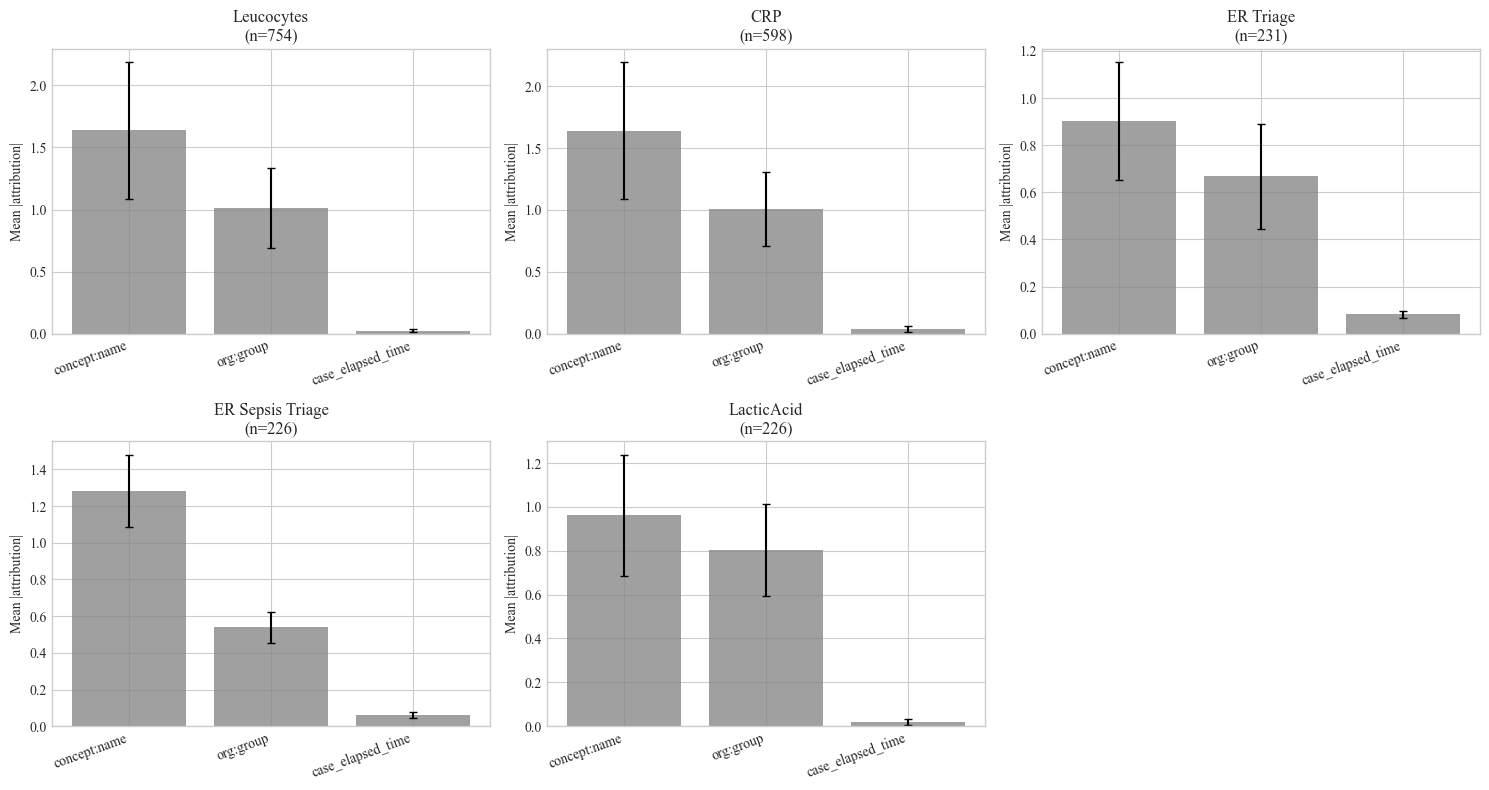

In [32]:
# Bar charts per top-5 predicted activity
n_activities = min(5, len(top_activities))
n_cols = min(3, n_activities)
n_rows = (n_activities + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten() if n_activities > 1 else [axes]

colors = '#888888'  # neutral grey applied uniformly to all bars
for idx, activity in enumerate(top_activities[:n_activities]):
    ax = axes[idx]
    sub = results_df[results_df['predicted_activity'] == activity]
    means = sub[available_features].mean()
    stds = sub[available_features].std()
    ax.bar(range(len(available_features)), means, yerr=stds, capsize=3,
           color=colors, alpha=0.8)
    ax.set_xticks(range(len(available_features)))
    ax.set_xticklabels(available_features, rotation=20, ha='right')
    ax.set_ylabel('Mean |attribution|')
    ax.set_title(f'{activity}\n(n={len(sub)})')
for idx in range(n_activities, len(axes)):
    axes[idx].axis('off')

#plt.suptitle(f'Feature Attribution by Predicted Activity ({SPEC.name})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


,predicted_activity,Count,concept:name,org:group,case_elapsed_time
0,Leucocytes,754,1.636912,1.011865,0.023764
1,CRP,598,1.639531,1.004302,0.036705
2,ER Triage,231,0.902805,0.668025,0.081842
3,ER Sepsis Triage,226,1.281907,0.538118,0.062477
4,LacticAcid,226,0.961329,0.802768,0.018230


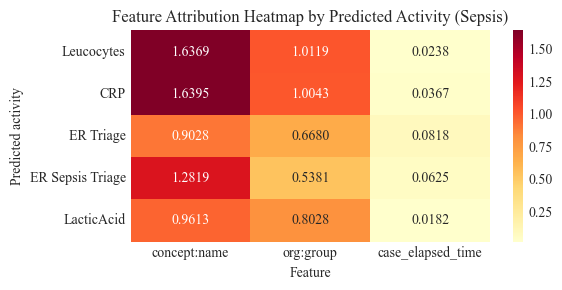

In [24]:
# Heatmap: activity x feature
rows = []
for activity in top_activities:
    sub = results_df[results_df['predicted_activity'] == activity]
    # Use a column name that won't clash with any entry in `available_features`.
    # Previously this was 'Activity', which is also a feature name on some
    # datasets — the per-feature loop below would overwrite it with numeric
    # means, then set_index('Activity') would drop it from columns and the
    # subsequent [available_features] lookup KeyError'd.
    row = {'predicted_activity': activity, 'Count': len(sub)}
    for feat in available_features:
        row[feat] = sub[feat].mean()
    rows.append(row)
summary_df = pd.DataFrame(rows)
display(summary_df)

heatmap_data = summary_df.set_index('predicted_activity')[available_features]
fig, ax = plt.subplots(figsize=(max(6, len(available_features) * 1.2),
                                max(3, len(top_activities) * 0.6)))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.4f', ax=ax)
ax.set_title(f'Feature Attribution Heatmap by Predicted Activity ({SPEC.name})')
ax.set_ylabel('Predicted activity')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()


## 7. Save Results

In [25]:
mode_suffix = '_test' if TEST_MODE else '_full'
output_dir = _camargo_dir / 'results'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f'dataset_attribution_camargo_bpic17{mode_suffix}.pkl'
with output_path.open('wb') as f:
    pickle.dump({
        'results_df': results_df,
        'avg_attribution': avg_attribution.to_dict(),
        'activity_summary': summary_df,
        'spec_name': SPEC.name,
        'test_mode': TEST_MODE,
        'features': available_features,
    }, f)
print(f'Results saved to: {output_path}')


Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/camargo/results/dataset_attribution_camargo_bpic17_full.pkl


## 8. Summary

In [26]:
print('=' * 80)
print(f'SUMMARY: Dataset-Level Attribution Analysis ({SPEC.name})')
print('=' * 80)
print(f'Mode: {"TEST" if TEST_MODE else "FULL"}')
print(f'Prefixes analyzed: {len(results_df)}')
print(f'EOS-target prefixes: {(results_df["actual_next_activity"] == "EOS").sum()}')
print(f'Total input features: {len(available_features)}')

print('\n--- Average Feature Attribution ---')
sorted_attrs = avg_attribution[available_features].sort_values(ascending=False)
for feat in sorted_attrs.index:
    print(f'{feat:25s}: {sorted_attrs[feat]:.6f}')

print('\n--- Top Predicted Activities ---')
for act in top_activities[:5]:
    print(f'{act}: {activity_counts[act]} predictions')


SUMMARY: Dataset-Level Attribution Analysis (Sepsis)
Mode: FULL
Prefixes analyzed: 2813
EOS-target prefixes: 209
Total input features: 3

--- Average Feature Attribution ---
concept:name             : 1.459666
org:group                : 1.032362
case_elapsed_time        : 0.040990

--- Top Predicted Activities ---
Leucocytes: 754 predictions
CRP: 598 predictions
ER Triage: 231 predictions
ER Sepsis Triage: 226 predictions
LacticAcid: 226 predictions
